In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('dataset/data_third_version.csv')

Переименование колонок

In [3]:
# Переименование в snake_case для удобства работы и соответствия Python-стилю
df = df.rename(columns={
    'Price':            'price',
    'Metro station':    'metro_station',
    'Minutes to metro': 'minutes_to_metro',
    'Number of rooms':  'rooms',
    'Area':             'area',
    'Floor':            'floor',
    'Number of floors': 'total_floors',
    'Renovation':       'renovation',
})

print("Колонки после переименования:")
print(df.columns.tolist())
print(f"\nРазмер: {df.shape}")


Колонки после переименования:
['price', 'metro_station', 'minutes_to_metro', 'rooms', 'area', 'floor', 'total_floors', 'renovation']

Размер: (11113, 8)


Создание новых признаков

In [4]:
import numpy as np

# Относительная высота этажа: 0 = первый, 1 = последний
df['floor_ratio'] = df['floor'] / df['total_floors']

# Бинарный признак: первый этаж
df['is_first_floor'] = (df['floor'] == 1).astype(int)

# Бинарный признак: последний этаж
df['is_last_floor'] = (df['floor'] == df['total_floors']).astype(int)

# Бинарный признак: студия (rooms == 0)
df['is_studio'] = (df['rooms'] == 0).astype(int)

# Логарифм площади (для линейной регрессии)
df['log_area'] = np.log1p(df['area'])

# Логарифм цены (целевая переменная для линейных моделей)
df['log_price'] = np.log1p(df['price'])

print(f"Размер после Feature Engineering: {df.shape}")
print(f"\nКолонки: {df.columns.tolist()}")


Размер после Feature Engineering: (11113, 14)

Колонки: ['price', 'metro_station', 'minutes_to_metro', 'rooms', 'area', 'floor', 'total_floors', 'renovation', 'floor_ratio', 'is_first_floor', 'is_last_floor', 'is_studio', 'log_area', 'log_price']


Контрольная проверка новых признаков

In [5]:
print("=" * 60)
print("СТАТИСТИКА НОВЫХ ПРИЗНАКОВ")
print("=" * 60)

# Floor ratio
print(f"\nfloor_ratio:")
print(df['floor_ratio'].describe())

# Бинарные признаки: доли
print(f"\nДоли бинарных признаков:")
print(f"  is_first_floor: {df['is_first_floor'].mean()*100:.1f}% ({df['is_first_floor'].sum()} объектов)")
print(f"  is_last_floor:  {df['is_last_floor'].mean()*100:.1f}% ({df['is_last_floor'].sum()} объектов)")
print(f"  is_studio:      {df['is_studio'].mean()*100:.1f}% ({df['is_studio'].sum()} объектов)")

# Проверка: суммарно first+last не должно быть > 100%
overlap = ((df['is_first_floor'] == 1) & (df['is_last_floor'] == 1)).sum()
print(f"\nПересечение first и last (одноэтажные дома): {overlap}")

# Логарифмические признаки
print(f"\nlog_area:  min={df['log_area'].min():.2f}, max={df['log_area'].max():.2f}, mean={df['log_area'].mean():.2f}")
print(f"log_price: min={df['log_price'].min():.2f}, max={df['log_price'].max():.2f}, mean={df['log_price'].mean():.2f}")


СТАТИСТИКА НОВЫХ ПРИЗНАКОВ

floor_ratio:
count    11113.000000
mean         0.515008
std          0.291277
min          0.025641
25%          0.250000
50%          0.500000
75%          0.764706
max          1.000000
Name: floor_ratio, dtype: float64

Доли бинарных признаков:
  is_first_floor: 9.4% (1047 объектов)
  is_last_floor:  8.2% (906 объектов)
  is_studio:      17.4% (1929 объектов)

Пересечение first и last (одноэтажные дома): 4

log_area:  min=2.48, max=5.99, mean=4.14
log_price: min=15.07, max=19.94, mean=17.03


Проверка эффекта логарифмирования

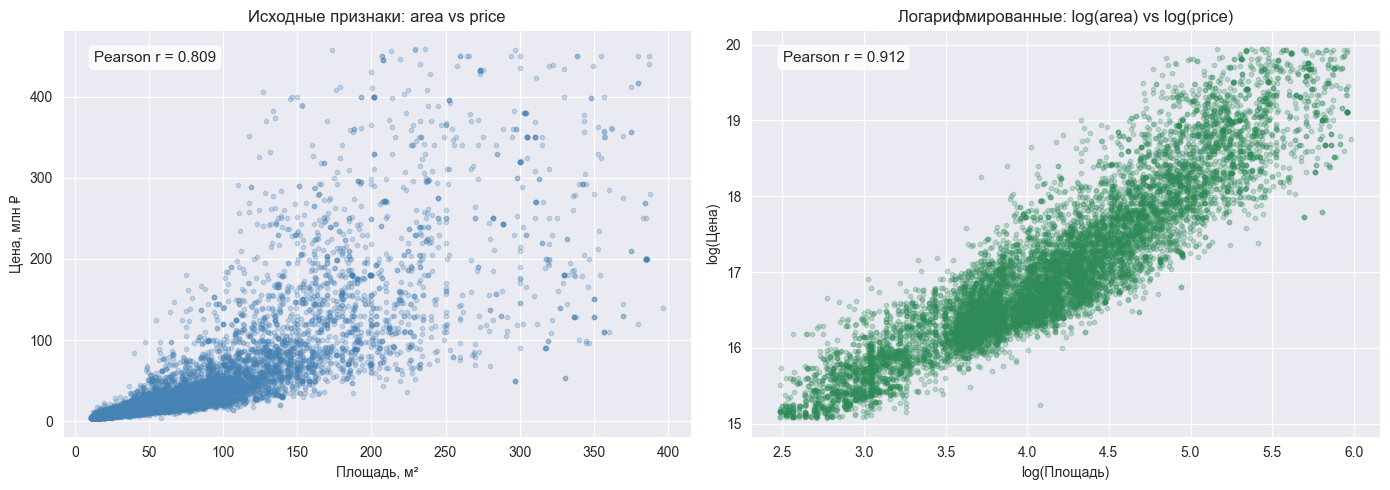

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Исходные данные
axes[0].scatter(df['area'], df['price'] / 1e6, alpha=0.25, s=10, color='steelblue')
axes[0].set_title('Исходные признаки: area vs price')
axes[0].set_xlabel('Площадь, м²')
axes[0].set_ylabel('Цена, млн ₽')

# Логарифмированные данные
axes[1].scatter(df['log_area'], df['log_price'], alpha=0.25, s=10, color='seagreen')
axes[1].set_title('Логарифмированные: log(area) vs log(price)')
axes[1].set_xlabel('log(Площадь)')
axes[1].set_ylabel('log(Цена)')

# Корреляции для подписи
corr_orig = df[['area', 'price']].corr().iloc[0, 1]
corr_log = df[['log_area', 'log_price']].corr().iloc[0, 1]
axes[0].text(0.05, 0.95, f'Pearson r = {corr_orig:.3f}', transform=axes[0].transAxes,
             fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
axes[1].text(0.05, 0.95, f'Pearson r = {corr_log:.3f}', transform=axes[1].transAxes,
             fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('reports/06_log_transformation_effect.png', dpi=150, bbox_inches='tight')
plt.show()


In [7]:
df.to_csv('dataset/data_engineered_1.csv', index=False)